# 9 · Behaviour trees

Decision logic for a robot: sequences, fallbacks, decorators and a blackboard — run by the C++ engine, with
leaves written in Python that call the planners of Part I.

In [1]:
# Installs the module when it is missing (e.g. on Colab); a local `pip install -e .` is used as is.
import importlib.util

if importlib.util.find_spec("motion_planning") is None:
    %pip install -q git+https://github.com/Rudip1/learn-motion-planning

## Recap

Theory: [`1_theory/09_behavior_trees.md`](../../1_theory/09_behavior_trees.md).

- The root is ticked every period; nodes return SUCCESS, FAILURE or RUNNING.
- Sequence (9.1): the first child that does not succeed decides. Fallback (9.2): the first that does not fail.
  Parallel (9.3): $M$ of $n$ successes.
- Reactive composites re-tick from the left and **halt** a running child they no longer reach; composites with
  memory resume the running child.
- Leaves share data through the blackboard. Design pattern: Fallback(goal reached, Sequence(preconditions,
  action)) (9.4).

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import motion_planning as mp
from motion_planning import bt, maps
from motion_planning.plotting import INK, SERIES, draw_tree, show_grid, use_style

use_style()
S, F, R = bt.Status.Success, bt.Status.Failure, bt.Status.Running

## Semantics by hand

### ✏️ Exercise 1 — one tick of a sequence and a fallback

Children are given as lists of the statuses they would return. Return `(status, number_of_children_ticked)` for
one tick of a Sequence (9.1) and of a Fallback (9.2).

In [3]:
def tick_sequence(statuses):
    for i, s in enumerate(statuses):
        if s != S:
            return s, i + 1
    return S, len(statuses)


def tick_fallback(statuses):
    for i, s in enumerate(statuses):
        if s != F:
            return s, i + 1
    return F, len(statuses)

In [4]:
rng = np.random.default_rng(9)
for _ in range(300):
    statuses = list(rng.choice([S, F, R], size=rng.integers(1, 6)))
    for mine, Composite in [(tick_sequence, bt.Sequence), (tick_fallback, bt.Fallback)]:
        counts = [0] * len(statuses)

        def leaf(i):
            def run(_bb):
                counts[i] += 1
                return statuses[i]
            return bt.Action(f"c{i}", run)

        node = Composite("n", [leaf(i) for i in range(len(statuses))])
        status = node.tick(bt.Blackboard())
        assert mine(statuses) == (status, sum(counts))
print("✓ sequence and fallback")

✓ sequence and fallback


## A robot mission

A robot patrols three waypoints in the rooms map. Each `MoveTo` plans with A* (chapter 4) on the inflated map the
first time it is ticked, then advances 0.3 m along its path per tick. Moving drains the battery; at the dock it
charges. Robot state lives on the blackboard.

In [5]:
rooms = maps.rooms()
inflated = mp.inflate(rooms, 0.3)
WAYPOINTS = {"A": (2.0, 2.8), "B": (8.0, 7.0), "C": (8.0, 1.5), "dock": (1.0, 7.0)}
STEP = 0.3


def plan(start, goal):
    r = mp.grid_search(inflated, inflated.world_to_cell(start), inflated.world_to_cell(goal))
    return [rooms.cell_center(tuple(c)) for c in r.path] if r.found else None

### ✏️ Exercise 2 — a `MoveTo` action

Return a `bt.Action` that, when ticked: plans a path from the robot's position (`bb["x"]`, `bb["y"]`) to the
waypoint if it has none (FAILURE if A* finds none); moves the robot up to `STEP` metres along it, draining
`bb["battery"]` by 1 per metre; returns SUCCESS on arrival and RUNNING otherwise. Its halt callback must drop the
stored path, so that a preempted MoveTo replans from wherever the robot is when it resumes.

In [6]:
def move_to(name, use_halt=True):
    goal = np.array(WAYPOINTS[name])
    state = {"path": None, "i": 0}

    def run(bb):
        pos = np.array([bb.number("x"), bb.number("y")])
        if state["path"] is None:
            state["path"], state["i"] = plan(pos, goal), 0
            if state["path"] is None:
                return F
        budget = STEP
        while budget > 0 and state["i"] < len(state["path"]):
            target = state["path"][state["i"]]
            d = np.linalg.norm(target - pos)
            if d <= budget:
                pos, budget, state["i"] = target, budget - d, state["i"] + 1
            else:
                pos, budget = pos + budget * (target - pos) / d, 0.0
        bb["battery"] = bb.number("battery") - (STEP - budget)
        bb["x"], bb["y"] = float(pos[0]), float(pos[1])
        if state["i"] >= len(state["path"]):
            state["path"] = None
            return S
        return R

    def halt():
        state["path"] = None

    return bt.Action(f"MoveTo {name}", run, halt if use_halt else None)

battery: min 23.2 %, final 95.5 %


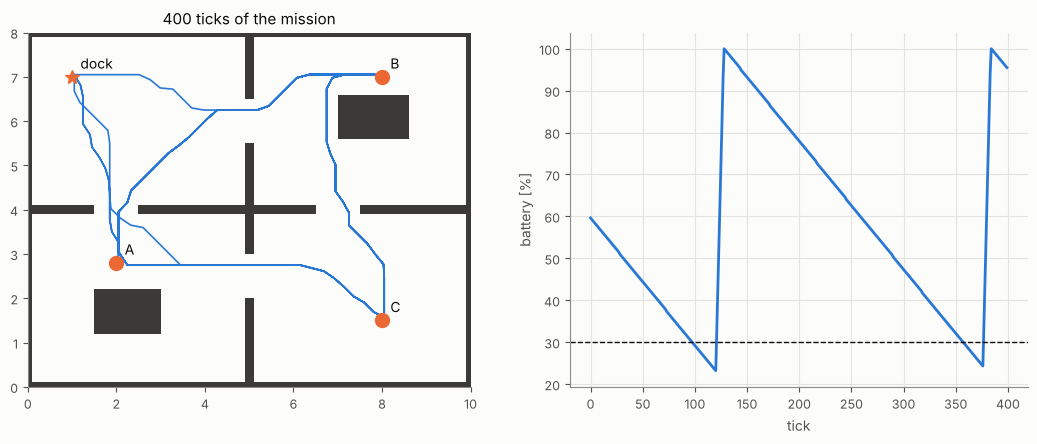

In [7]:
def charge(bb):
    bb["battery"] = min(100.0, bb.number("battery") + 10.0)
    bb["charging"] = bb.number("battery") < 100.0
    return S if bb.number("battery") >= 100.0 else R


def make_tree(fixed=True, memory_patrol=False, use_halt=True):
    patrol = bt.Sequence("patrol", [move_to(w, use_halt) for w in "ABC"], memory=True)
    work = [bt.compare("BatteryOk", "battery", ">=", 30.0), bt.Repeat("forever", patrol, 1000)]
    if fixed:
        work.insert(0, bt.Inverter("not", bt.compare("Charging", "charging", "==", 1.0)))
    recharge = bt.Sequence("recharge", [move_to("dock", use_halt), bt.Action("Charge", charge)], memory=True)
    tree = bt.Tree(bt.Fallback("root", [bt.Sequence("work", work, memory=memory_patrol), recharge]))
    bb = tree.blackboard
    bb["x"], bb["y"], bb["battery"], bb["charging"] = 2.0, 2.8, 60.0, False
    return tree


def run(tree, ticks=400):
    log = []
    for _ in range(ticks):
        tree.tick()
        bb = tree.blackboard
        log.append((bb.number("x"), bb.number("y"), bb.number("battery")))
    return np.array(log)


log = run(make_tree())
print(f"battery: min {log[:, 2].min():.1f} %, final {log[-1, 2]:.1f} %")
assert log[:, 2].min() > 0

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))
show_grid(ax, rooms)
ax.plot(log[:, 0], log[:, 1], color=SERIES[0], lw=1.2)
for name, p in WAYPOINTS.items():
    ax.plot(*p, "*" if name == "dock" else "o", color=SERIES[1], ms=10)
    ax.annotate(name, p, xytext=(6, 6), textcoords="offset points")
ax.set_title("400 ticks of the mission")
ax2.plot(log[:, 2], color=SERIES[0])
ax2.axhline(30, color=INK, ls="--", lw=1)
ax2.set_xlabel("tick")
ax2.set_ylabel("battery [%]")
plt.show()

The tree after the last tick (RUNNING branches in amber):

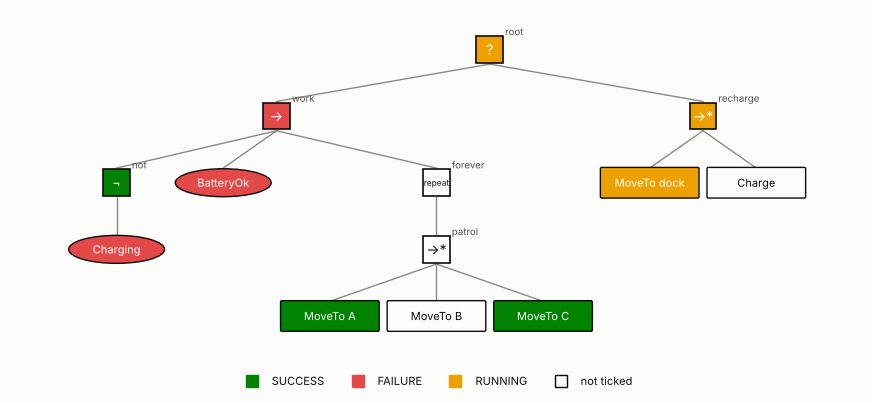

In [8]:
tree = make_tree()
run(tree, 120)
fig, ax = plt.subplots(figsize=(13, 4.5))
draw_tree(ax, tree.root, x_gap=1.6)
plt.show()

### 🔨 Break it — no hysteresis

Remove the `Charging` flag: the robot leaves the dock as soon as one tick of charging lifts it above 30 %.

In [9]:
naive = run(make_tree(fixed=False))
print(f"with hysteresis: max battery after the first charge {log[100:, 2].max():.0f} %; "
      f"without: {naive[100:, 2].max():.0f} %")

with hysteresis: max battery after the first charge 100 %; without: 37 %


### 🔨 Break it — memory where reactivity was needed

Make the `work` sequence remember its running child: once Patrol runs, BatteryOk is never checked again.

In [10]:
mem = run(make_tree(memory_patrol=True))
print(f"battery with a memory sequence: min {mem[:, 2].min():.1f} % — the robot never goes to charge")

battery with a memory sequence: min -62.4 % — the robot never goes to charge


### 🔨 Break it — no halt

Without the halt callback, a preempted MoveTo keeps its old path and index. When it resumes after charging, it
heads for the next point of a path planned from somewhere else — straight through the walls. Count the moves
that cross an obstacle (exact segment test, chapter 2).

In [11]:
def wall_crossings(log):
    return sum(not mp.segment_free(rooms, a[:2], b[:2]) for a, b in zip(log[:-1], log[1:]))


no_halt = run(make_tree(use_halt=False))
print(f"moves through walls: with halt {wall_crossings(log)}, without halt {wall_crossings(no_halt)}")

moves through walls: with halt 0, without halt 4


### ✏️ Exercise 3 — a safety guard

Put a guard in front of the mission: `Sequence(Inverter(bumper == 1), mission root)`, reactive. While the bumper is
pressed the guard fails and halts the running MoveTo, so the robot must not move on that tick; when it is
released the mission resumes. Build the guarded tree.

In [12]:
mission = make_tree()
guarded = bt.Tree(bt.Sequence("guard", [bt.Inverter("no bump", bt.compare("Bumper", "bumper", "==", 1.0)),
                                       mission.root]))
for k in ["x", "y", "battery", "charging"]:
    guarded.blackboard[k] = mission.blackboard[k]
guarded.blackboard["bumper"] = False

In [13]:
for _ in range(10):
    guarded.tick()
before = (guarded.blackboard.number("x"), guarded.blackboard.number("y"))
guarded.blackboard["bumper"] = True
assert guarded.tick() == F
assert (guarded.blackboard.number("x"), guarded.blackboard.number("y")) == before
guarded.blackboard["bumper"] = False
assert guarded.tick() == R
print("✓ the bumper stops the mission; releasing it resumes (with a fresh plan, thanks to halt)")

✓ the bumper stops the mission; releasing it resumes (with a fresh plan, thanks to halt)


## What to remember

- Ticks, three statuses, and two composites: Sequence (first non-success decides), Fallback (first non-failure).
- Reactive composites re-check conditions every tick and must halt what they preempt; memory is for steps that
  must not be redone.
- Conditions near a threshold need hysteresis, or reactive trees chatter.
- Leaves are small and fast; the blackboard carries the data; the planners of Part I become actions.